In [1]:
import os
import pandas as pd
import swifter 
import numpy as np
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

nltk_path = os.path.join(os.path.dirname(nltk.__file__), 'nltk_data')
nltk.data.path.append(nltk_path)
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

force_prep = False # set to True if we want to preprocess data by force

if os.path.exists('balanced_polusa3.csv') and not force_prep:
    prepped_polusa = pd.read_csv('balanced_polusa3.csv')
    X_train, X_test, y_train, y_test = train_test_split(prepped_polusa['text'], prepped_polusa['label'], test_size=0.2, random_state=42)
else:
    # Combine all POLUSA dataset
    files = [
            # 'polusa/2017_1.csv', 'polusa/2017_2.csv', 
            # 'polusa/2018_1.csv', 'polusa/2018_2.csv',
            'polusa/2019_1.csv', 'polusa/2019_2.csv'
            ]

    polusa = [pd.read_csv(f) for f in files]
    combined_polusa = pd.concat(polusa, ignore_index=True)

    # Drop undefined labels
    combined_polusa = combined_polusa[combined_polusa['political_leaning'] != 'UNDEFINED']

    # Drop non-predictive columns
    cd_polusa = combined_polusa.drop(['id', 'url', 'date_publish', 'authors', 'domain'], axis=1)

    # Combine article into one single text
    cd_polusa['text'] = (cd_polusa['outlet'].fillna('') + ' ' + 
                        cd_polusa['headline'].fillna('') + ' ' + 
                        cd_polusa['lead'].fillna('') + ' ' + 
                        cd_polusa['body'].fillna(''))

    # Convert political leaning into numbers
    # Center = 0, Left = 1, Right = 2
    le = LabelEncoder()
    cd_polusa['label'] = le.fit_transform(cd_polusa['political_leaning'])
    
    cleaned_polusa = cd_polusa[['text','label']]
    cleaned_polusa.head()

    X_train, X_test, y_train, y_test = train_test_split(cleaned_polusa['text'], cleaned_polusa['label'], test_size=0.2, random_state=42)

    stop_words = set(stopwords.words('english'))
    def preprocess(txt):
        txt = txt.lower()
        txt = ''.join([c for c in txt if c not in string.punctuation])
        toks = word_tokenize(txt)
        toks = [word for word in toks if word not in stop_words]
        return ' '.join(toks)

    X_train = X_train.swifter.apply(preprocess)
    X_test = X_test.swifter.apply(preprocess)

    prepped_polusa = pd.DataFrame({'text': pd.concat([X_train, X_test]), 'label': pd.concat([y_train, y_test])})
    prepped_polusa.to_csv('prepped_polusa.csv', index=False)
    prepped_polusa.head()

X_train
X_test



[nltk_data] Downloading package stopwords to /home/alex/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/alex/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/alex/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


194949    guardian ubers head hr resigns amid allegation...
161875    fox news outside group finds green new deal em...
61912     fox news philippines objects chinas naming und...
35966     new york times jamal khashoggi among journalis...
143596    new york times taliban capture 150 afghan sold...
                                ...                        
205009    guardian jamal khashoggi killing premeditated ...
206825    cbs news trump proposes meeting kim jong un sh...
106710    nbc news house democrats probe trumps possible...
82982     reuters gm add shift tennessee plant making su...
194779    reuters update 3argentinas peso rebounds centr...
Name: text, Length: 42000, dtype: object

In [2]:
print(prepped_polusa.columns)
print(prepped_polusa.dtypes)

print(prepped_polusa['label'].value_counts())

Index(['text', 'label'], dtype='object')
text     object
label     int64
dtype: object
label
0    70000
1    70000
2    70000
Name: count, dtype: int64


In [3]:
from keras._tf_keras.keras.preprocessing.text import Tokenizer
from keras._tf_keras.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)
X_train = tokenizer.texts_to_sequences(X_train)
X_test = tokenizer.texts_to_sequences(X_test)

max_length = 100
X_train = pad_sequences(X_train, maxlen=max_length, padding='post')
X_test = pad_sequences(X_test, maxlen=max_length, padding='post')

2025-10-01 07:08:21.051775: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-01 07:08:21.312333: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759273701.410737   66655 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759273701.436794   66655 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1759273701.621346   66655 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [4]:
# Load GloVe
embeddings_index = {}
with open('glove/glove.6B.100d.txt', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f'Found {len(embeddings_index)} word vectors.')

Found 400000 word vectors.


In [5]:
# Load Counterfitted GloVe
counter_embeddings = {}
with open('counter-fitting/results/c_glove30.txt', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        counter_embeddings[word] = coefs

print(f'Found {len(counter_embeddings)} word vectors.')

Found 400000 word vectors.


In [ ]:
retro_embeddings = {}
with open('rWN+_glove40.txt', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        retro_embeddings[word] = coefs

print(f'Found {len(retro_embeddings)} word vectors.')

Found 400000 word vectors.


In [27]:
# Prepare embedding matrix
embedding_dim = 100
word_index = tokenizer.word_index
num_words = len(word_index) + 1
embedding_matrix = np.zeros((num_words, embedding_dim))

for word, i in word_index.items():
    embedding_vector = retro_embeddings.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector
    # else:
    #     og_vector = embeddings_index.get(word)
    #     if og_vector is not None:
    #         embedding_matrix[i] = og_vector

In [28]:
import tensorflow as tf
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
        tf.config.experimental.set_visible_devices(gpus[0], 'GPU')
        print('Using GPU:', gpus[0])
    except RuntimeError as e:
        print(e)
else:
    print('GPU Not found')

Using GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [29]:
from keras._tf_keras.keras.models import Sequential
from keras._tf_keras.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, GlobalAveragePooling1D
from keras._tf_keras.keras.optimizers import Adam
from keras._tf_keras.keras.regularizers import l2
from keras_self_attention import SeqSelfAttention

# Clear previous models and free memory
import gc
tf.keras.backend.clear_session()
gc.collect()

model = Sequential()

# GloVe-based Embedding layer
model.add(Embedding(
    input_dim=num_words,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    trainable=False   # keep GloVe fixed initially
))

# First Bidirectional BiLSTM layer 
model.add(Bidirectional(LSTM(128, dropout=0.5, return_sequences=True)))

# # Second Bidirectional BiLSTM layer 
model.add(Bidirectional(LSTM(128, dropout=0.5)))

# Attention layer
# model.add(SeqSelfAttention(
#     attention_activation='tanh'
# ))  # pip install keras-self-attention
# model.add(GlobalAveragePooling1D())

# Fully connected layers
# model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.01)))
# model.add(Dropout(0.4))

# Template for 1-layer BiLSTM
# model.add(Bidirectional(LSTM(32, dropout=0.1)))
# model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.01)))
# model.add(Dropout(0.1))

# Output layer
model.add(Dense(3, activation='softmax'))


In [30]:
from keras._tf_keras.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss',
                           patience=3,  # how many epochs with no improvement before stopping
                           restore_best_weights=True)

In [31]:
import keras._tf_keras.keras.backend as keras_backend

# Class weights for prepped_polusa.csv
class_weights = {
    0: 1.0,
    1: 1.0,
    2: 1.0
}

# Class weights for prepped_polusa2.csv (larger dataset)
# class_weights = {
#     0: 0.956, 
#     1: 0.789,  
#     2: 1.457   
# }

gc.collect()  
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(np.array(X_train), np.array(y_train), epochs=40, batch_size=356, class_weight=class_weights, validation_data=(X_test, y_test), callbacks=[early_stop])
gc.collect()

Epoch 1/40
472/472 ━━━━━━━━━━━━━━━━━━━━ 51s 100ms/step - accuracy: 0.5574 - loss: 0.9107 - val_accuracy: 0.6909 - val_loss: 0.6844
Epoch 2/40
472/472 ━━━━━━━━━━━━━━━━━━━━ 53s 112ms/step - accuracy: 0.6618 - loss: 0.7329 - val_accuracy: 0.7343 - val_loss: 0.6039
Epoch 3/40
472/472 ━━━━━━━━━━━━━━━━━━━━ 53s 112ms/step - accuracy: 0.7104 - loss: 0.6486 - val_accuracy: 0.7480 - val_loss: 0.5607
Epoch 4/40
472/472 ━━━━━━━━━━━━━━━━━━━━ 54s 115ms/step - accuracy: 0.7313 - loss: 0.6044 - val_accuracy: 0.7607 - val_loss: 0.5372
Epoch 5/40
472/472 ━━━━━━━━━━━━━━━━━━━━ 57s 120ms/step - accuracy: 0.7447 - loss: 0.5737 - val_accuracy: 0.7698 - val_loss: 0.5178
Epoch 6/40
472/472 ━━━━━━━━━━━━━━━━━━━━ 56s 119ms/step - accuracy: 0.7530 - loss: 0.5596 - val_accuracy: 0.7744 - val_loss: 0.5071
Epoch 7/40
472/472 ━━━━━━━━━━━━━━━━━━━━ 51s 108ms/step - accuracy: 0.7604 - loss: 0.5388 - val_accuracy: 0.7799 - val_loss: 0.4965
Epoch 8/40
472/472 ━━━━━━━━━━━━━━━━━━━━ 56s 119ms/step - accuracy: 0.7684 - loss: 0

14731

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 26ms/step
Accuracy: 0.8487
Precision: 0.8498
Recall: 0.8487
F1 Score: 0.8485

Confusion Matrix:
[[12291   762   785]
 [ 1211 11920   875]
 [ 1364  1358 11434]]


5182

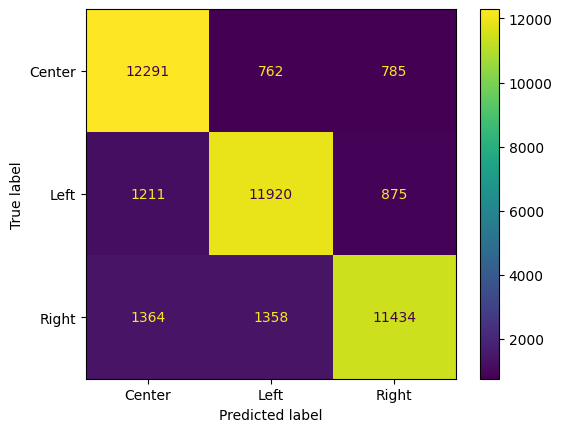

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Compute evaluation metrics
print(f'Accuracy: {accuracy_score(y_test, y_pred_classes):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_classes, average='weighted'):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_classes, average='weighted'):.4f}')
print(f'F1 Score: {f1_score(y_test, y_pred_classes, average='weighted'):.4f}')

# Show confusion matrix
print('\nConfusion Matrix:')
conf_matrix = confusion_matrix(y_test, y_pred_classes)
print(conf_matrix)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Center', 'Left', 'Right'])
disp.plot()
gc.collect()

In [33]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 100)       │    50,692,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 100, 256)       │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,581,223 (200.58 MB)

 Trainable params: 629,507 (2.40 MB)

 Non-trainable params: 50,692,700 (193.38 MB)

 Optimizer params: 1,259,016 (4.80 MB)

None


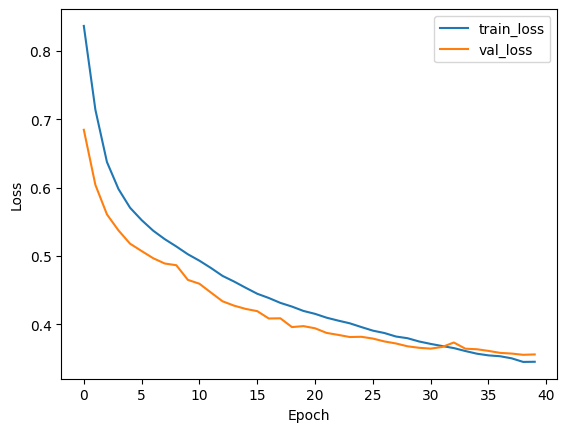

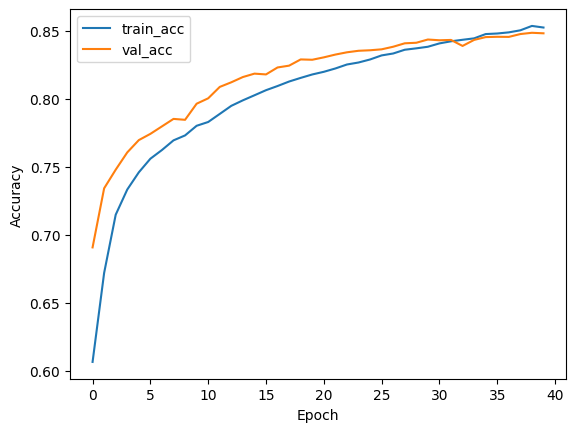

In [34]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [35]:
# Save the full model
# model.save('polusa_BiLSTM_v2.keras')